In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset
df=pd.read_csv("dataset_penjualan.csv")

### A. Exploratory Data and Data Cleaning
1. Tampilkan 5 data pertama dan 5 data terakhir.
2. Hitung jumlah nilai kosong (NaN) pada kolom 'Jumlah' dan 'Harga Satuan'.
3. Buat strategi pengisian nilai kosong (mean/median), lalu terapkan ke dataset.
4. Tampilkan distribusi 'Jumlah' dan 'Harga Satuan' menggunakan histogram dan boxplot.


In [3]:
# 1. Display the first 5 rows of the dataset
df.head(5)

,ID Transaksi,Tanggal,Nama Pelanggan,Kota,Kategori Produk,Jumlah,Harga Satuan,Total
0,TX1000,2023-07-30,Prayoga Hartati,Jakarta,Elektronik,NaN,114196.0,NaN
1,TX1001,2023-07-20,Latika Wastuti,Bandung,Pakaian,2.0,192964.0,385928.0
2,TX1002,2023-10-31,dr. Dalima Simbolon,Jakarta,Olahraga,7.0,58331.0,408317.0
3,TX1003,2025-01-21,Lala Astuti,Jakarta,Elektronik,4.0,110990.0,443960.0
4,TX1004,2024-03-09,Umi Hutapea,Makassar,Olahraga,1.0,197127.0,197127.0


In [4]:
# 1. Display the last 5 rows of the dataset
df.tail(5)

,ID Transaksi,Tanggal,Nama Pelanggan,Kota,Kategori Produk,Jumlah,Harga Satuan,Total
95,TX1095,2025-02-18,Kania Nashiruddin,Surabaya,Makanan,1.0,143797.0,143797.0
96,TX1096,2024-06-05,"T. Yusuf Zulaika, M.Ak",Bandung,Pakaian,2.0,142714.0,285428.0
97,TX1097,2024-09-26,"Darimin Ramadan, S.T.",Makassar,Perabot,10.0,90515.0,905150.0
98,TX1098,2024-02-12,Almira Waluyo,Bandung,Pakaian,3.0,158080.0,474240.0
99,TX1099,2024-05-13,"Dt. Maryanto Suryatmi, S.Pd",Jakarta,Pakaian,6.0,NaN,NaN


In [5]:
# 2. Check Missing Values
df[['Jumlah', 'Harga Satuan']].isnull().sum()

Jumlah          10
Harga Satuan     8
dtype: int64

In [6]:
# 2. Display row that contain missing values in the dataset
df[df[['Jumlah', 'Harga Satuan']].isnull().any(axis=1)]

,ID Transaksi,Tanggal,Nama Pelanggan,Kota,Kategori Produk,Jumlah,Harga Satuan,Total
0,TX1000,2023-07-30,Prayoga Hartati,Jakarta,Elektronik,NaN,114196.0,NaN
10,TX1010,2024-03-02,"Rafi Budiman, S.Farm",Surabaya,Olahraga,NaN,61390.0,NaN
15,TX1015,2024-10-26,Rahmi Narpati,Jakarta,Perabot,5.0,NaN,NaN
20,TX1020,2024-09-30,"Purwadi Adriansyah, S.Gz",Surabaya,Elektronik,4.0,NaN,NaN
22,TX1022,2024-01-04,Cindy Nasyidah,Bandung,Olahraga,NaN,105738.0,NaN
25,TX1025,2023-11-29,Mumpuni Halimah,Makassar,Makanan,10.0,NaN,NaN
37,TX1037,2023-11-13,"R. Paris Yulianti, S.Ked",Bandung,Olahraga,9.0,NaN,NaN
39,TX1039,2023-07-10,Kamaria Agustina,Jakarta,Makanan,NaN,112770.0,NaN
44,TX1044,2025-04-02,"Cut Hasna Pratiwi, S.E.",Bandung,Olahraga,NaN,131714.0,NaN
45,TX1045,2024-01-01,Ika Dongoran,Medan,Makanan,NaN,185679.0,NaN


In [7]:
# 3. Fill Missing Values
df['Jumlah'].fillna(df['Jumlah'].median(), inplace=True)
df['Harga Satuan'] = df.groupby('Kategori Produk')['Harga Satuan'].transform(lambda x: x.fillna(x.median()))

df['Total'] = df['Jumlah'] * df['Harga Satuan']
df

,ID Transaksi,Tanggal,Nama Pelanggan,Kota,Kategori Produk,Jumlah,Harga Satuan,Total
0,TX1000,2023-07-30,Prayoga Hartati,Jakarta,Elektronik,5.0,114196.0,570980.0
1,TX1001,2023-07-20,Latika Wastuti,Bandung,Pakaian,2.0,192964.0,385928.0
2,TX1002,2023-10-31,dr. Dalima Simbolon,Jakarta,Olahraga,7.0,58331.0,408317.0
3,TX1003,2025-01-21,Lala Astuti,Jakarta,Elektronik,4.0,110990.0,443960.0
4,TX1004,2024-03-09,Umi Hutapea,Makassar,Olahraga,1.0,197127.0,197127.0
...,...,...,...,...,...,...,...,...
95,TX1095,2025-02-18,Kania Nashiruddin,Surabaya,Makanan,1.0,143797.0,143797.0
96,TX1096,2024-06-05,"T. Yusuf Zulaika, M.Ak",Bandung,Pakaian,2.0,142714.0,285428.0
97,TX1097,2024-09-26,"Darimin Ramadan, S.T.",Makassar,Perabot,10.0,90515.0,905150.0
98,TX1098,2024-02-12,Almira Waluyo,Bandung,Pakaian,3.0,158080.0,474240.0


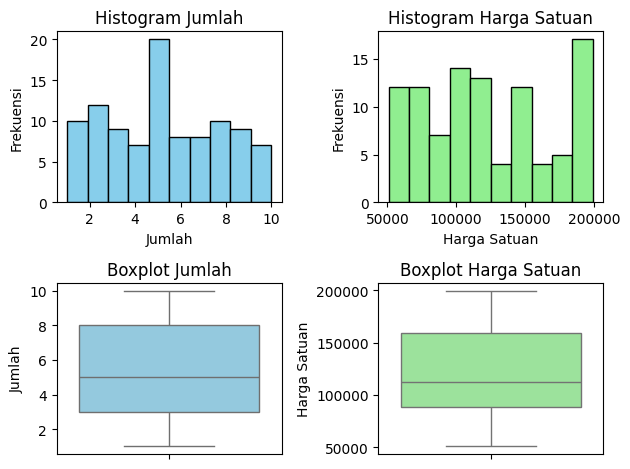

In [8]:
# 4.  Show data distribution
# Histogram
plt.subplot(2, 2, 1)
plt.hist(df['Jumlah'], color='skyblue', edgecolor='black')
plt.title('Histogram Jumlah')
plt.xlabel('Jumlah')
plt.ylabel('Frekuensi')

plt.subplot(2, 2, 2)
plt.hist(df['Harga Satuan'], color='lightgreen', edgecolor='black')
plt.title('Histogram Harga Satuan')
plt.xlabel('Harga Satuan')
plt.ylabel('Frekuensi')

# Boxplot
plt.subplot(2, 2, 3)
sns.boxplot(y=df['Jumlah'], color='skyblue')
plt.title('Boxplot Jumlah')

plt.subplot(2, 2, 4)
sns.boxplot(y=df['Harga Satuan'], color='lightgreen')
plt.title('Boxplot Harga Satuan')

plt.tight_layout()
plt.show()



### B. Analisis Penjualan
5. Hitung total penjualan untuk seluruh data.
6. Tampilkan kategori produk dengan total penjualan tertinggi.
7. Kota mana yang memiliki jumlah transaksi terbanyak?
8. Hitung rata-rata jumlah produk per transaksi.
9. Siapa pelanggan dengan total pembelian terbesar?
10. Hitung jumlah transaksi yang terjadi selama tahun 2024.
11. Produk kategori apa yang paling sering dibeli di Bandung?
12. Hitung total penjualan khusus untuk kategori Elektronik.
13. Hitung rata-rata harga satuan seluruh produk.


In [9]:
# 5. Calculate Total Sales
print("Total Penjualan: ", df['Total'].sum())

Total Penjualan:  62788831.5


In [10]:
# 6. Show Highest Total Sales by Product Category
print(df.groupby('Kategori Produk')['Total'].sum().sort_values(ascending=False))
print("-------------------------------------------------")
print("Kategori Produk dengan Penjualan Tertinggi:")
print(df.groupby('Kategori Produk')['Total'].sum().idxmax())

Kategori Produk
Pakaian       14420798.0
Makanan       13194319.0
Elektronik    12627797.0
Perabot       11725521.0
Olahraga      10820396.5
Name: Total, dtype: float64
-------------------------------------------------
Kategori Produk dengan Penjualan Tertinggi:
Pakaian


In [11]:
# 7. Show City with the Highest Number of Transactions
transaksi_per_kota = df['Kota'].value_counts()
kota_terbanyak = transaksi_per_kota.idxmax()
jumlah_transaksi = transaksi_per_kota.max()
print(f"Kota dengan Jumlah Transaksi Terbanyak: {kota_terbanyak} ({jumlah_transaksi} transaksi)")

Kota dengan Jumlah Transaksi Terbanyak: Bandung (27 transaksi)


In [12]:
# 8. Show the average sales amount
print("Rata-rata Jumlah Produk per Transaksi: ", df['Jumlah'].mean())

Rata-rata Jumlah Produk per Transaksi:  5.24


In [13]:
# 9. Show the customer with the highest total sales
print("Pelanggan dengan Penjualan Tertinggi:")
print(df.loc[df['Total'].idxmax(), ['Nama Pelanggan', 'Total']])

Pelanggan dengan Penjualan Tertinggi:
Nama Pelanggan    R. Soleh Pradipta, M.Kom.
Total                             1739070.0
Name: 52, dtype: object


In [14]:
# 10. Show the number of sales in 2024
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%Y-%m-%d')
df_2024 = df[df['Tanggal'].dt.year == 2024]
print("Jumlah Penjualan pada Tahun 2024: ", df_2024['Jumlah'].sum())

Jumlah Penjualan pada Tahun 2024:  260.0


In [15]:
# 11. Show the highest number of sales per category in Bandung city
print("Jumlah Penjualan per Kategori Produk di Kota Bandung:")
print(df[df['Kota'] == 'Bandung']['Kategori Produk'].value_counts().sort_values(ascending=False))
print("-------------------------------------------------")
kategori_terbanyak = df[df['Kota'] == 'Bandung']['Kategori Produk'].value_counts().idxmax()
print("Kategori Produk yang Paling Sering Dibeli di Bandung:", kategori_terbanyak)

Jumlah Penjualan per Kategori Produk di Kota Bandung:
Kategori Produk
Olahraga      7
Pakaian       6
Perabot       6
Makanan       6
Elektronik    2
Name: count, dtype: int64
-------------------------------------------------
Kategori Produk yang Paling Sering Dibeli di Bandung: Olahraga


In [16]:
# 12. Show the total sales of electronic products
print("Total Penjualan Produk Elektronik: ", df[df['Kategori Produk'] == 'Elektronik']['Total'].sum())

Total Penjualan Produk Elektronik:  12627797.0


In [17]:
# 13. Show the average unit price
print("Rata-rata Harga Satuan: ", df['Harga Satuan'].mean())

Rata-rata Harga Satuan:  123024.48


### C. Visualisasi Data
14. Buat line chart tren penjualan bulanan (jumlah transaksi & total penjualan).
15. Buat bar chart total penjualan per kategori produk.
16. Buat scatter plot antara 'Jumlah' dan 'Total' untuk melihat hubungan.

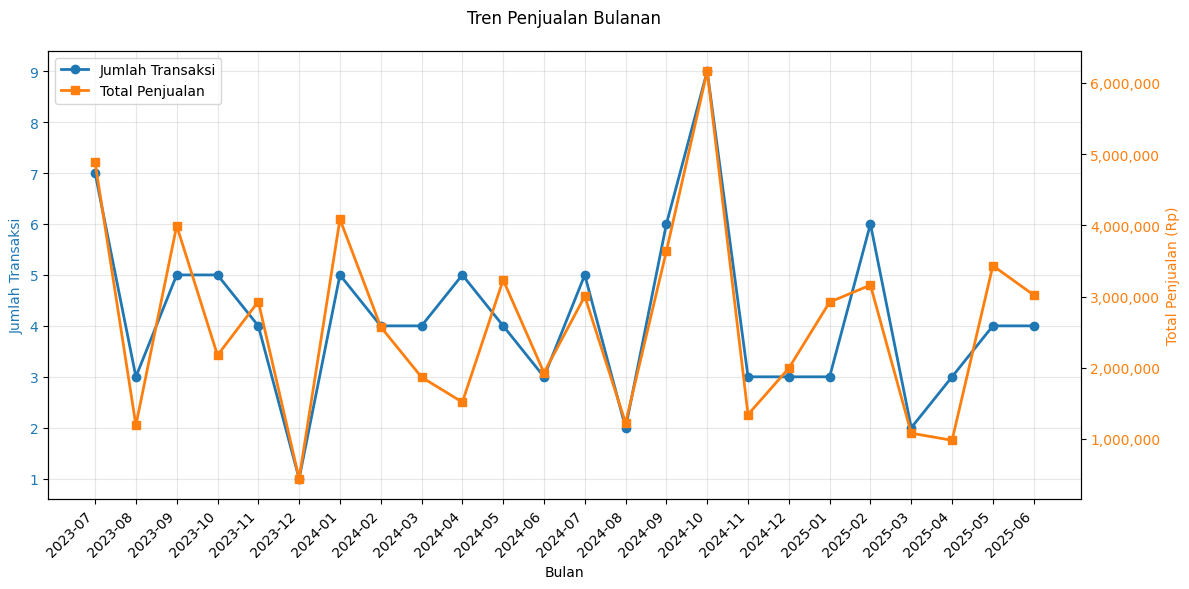


Statistik Bulanan:
Rata-rata jumlah transaksi: 4
Rata-rata total penjualan: Rp 2,616,201.31
Bulan dengan transaksi tertinggi: 2024-10
Bulan dengan penjualan tertinggi: 2024-10

Trend Analysis:
Pertumbuhan transaksi: -42.9%
Pertumbuhan penjualan: -38.1%


In [18]:
# 14. Line Chart of Monthly Sales Trends
# Prepare monthly data if not already done
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
monthly_data = df.groupby(df['Tanggal'].dt.to_period('M')).agg({
    'ID Transaksi': 'count',
    'Total': 'sum'
}).reset_index()

# Rename 'ID Transaksi' to 'Jumlah_Transaksi'
monthly_data = monthly_data.rename(columns={'ID Transaksi': 'Jumlah_Transaksi'})

# Convert period to string for better plotting
monthly_data['Tanggal'] = monthly_data['Tanggal'].astype(str)

# Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot jumlah transaksi
color1 = '#1f77b4'  # Blue
line1 = ax1.plot(monthly_data['Tanggal'], monthly_data['Jumlah_Transaksi'], 
                 color=color1, marker='o', linewidth=2,
                 label='Jumlah Transaksi')
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Jumlah Transaksi', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Create second y-axis for total penjualan
ax2 = ax1.twinx()
color2 = '#ff7f0e'  # Orange
line2 = ax2.plot(monthly_data['Tanggal'], monthly_data['Total'], 
                 color=color2, marker='s', linewidth=2,
                 label='Total Penjualan')
ax2.set_ylabel('Total Penjualan (Rp)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Format y-axis labels for total sales
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add title
plt.title('Tren Penjualan Bulanan', pad=20)

# Add legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Add grid
ax1.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Print summary statistics
print("\nStatistik Bulanan:")
print(f"Rata-rata jumlah transaksi: {monthly_data['Jumlah_Transaksi'].mean():.0f}")
print(f"Rata-rata total penjualan: Rp {monthly_data['Total'].mean():,.2f}")
print(f"Bulan dengan transaksi tertinggi: {monthly_data.loc[monthly_data['Jumlah_Transaksi'].idxmax(), 'Tanggal']}")
print(f"Bulan dengan penjualan tertinggi: {monthly_data.loc[monthly_data['Total'].idxmax(), 'Tanggal']}")
print("\nTrend Analysis:")
print(f"Pertumbuhan transaksi: {((monthly_data['Jumlah_Transaksi'].iloc[-1] / monthly_data['Jumlah_Transaksi'].iloc[0] - 1) * 100):.1f}%")
print(f"Pertumbuhan penjualan: {((monthly_data['Total'].iloc[-1] / monthly_data['Total'].iloc[0] - 1) * 100):.1f}%")

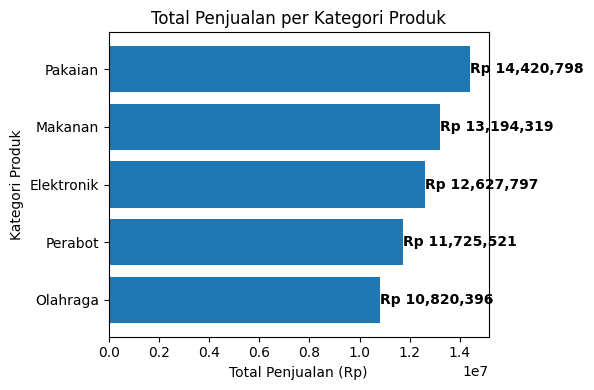

In [19]:
# 15. Calculate total sales per category
category_sales = df.groupby('Kategori Produk')['Total'].sum().sort_values(ascending=True)

# Create bar chart
plt.figure(figsize=(6, 4))
bars = plt.barh(category_sales.index, category_sales.values)
plt.title('Total Penjualan per Kategori Produk')
plt.xlabel('Total Penjualan (Rp)')
plt.ylabel('Kategori Produk')

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'Rp {width:,.0f}',
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

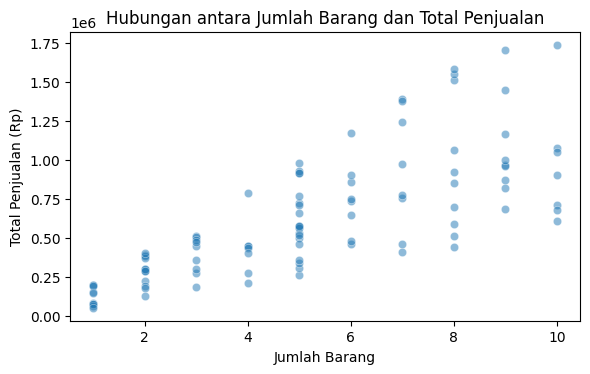


Koefisien korelasi antara Jumlah dan Total: 0.7567


In [20]:
# 16. Create scatter plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Jumlah', y='Total', alpha=0.5)
plt.title('Hubungan antara Jumlah Barang dan Total Penjualan')
plt.xlabel('Jumlah Barang')
plt.ylabel('Total Penjualan (Rp)')
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation = df['Jumlah'].corr(df['Total'])
print(f"\nKoefisien korelasi antara Jumlah dan Total: {correlation:.4f}")

### D. Machine Learning – Prediksi Penjualan
- Model 1: Linear Regression
17. Persiapkan data fitur 'Jumlah', 'Harga Satuan' dan target 'Total'.
18.	Split data: 80% untuk train, 20% untuk test.
19.	Buat model Linear Regression dan tampilkan MAE, RMSE, R² Score.
20.	Visualisasikan hasil prediksi dengan scatter plot (aktual vs prediksi).


In [21]:
# 17. Prepare data for regression analysis
X = df[['Jumlah', 'Harga Satuan']]
y = df['Total']

In [22]:
# 18. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# 19. Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

Linear Regression
Model Performance Metrics:
Mean Absolute Error (MAE): Rp 69,572.16
Root Mean Square Error (RMSE): Rp 115,364.88
R² Score: 0.8647

Model Parameters:
Slope (coefficient): 119,225.51
Intercept: -607,756.62


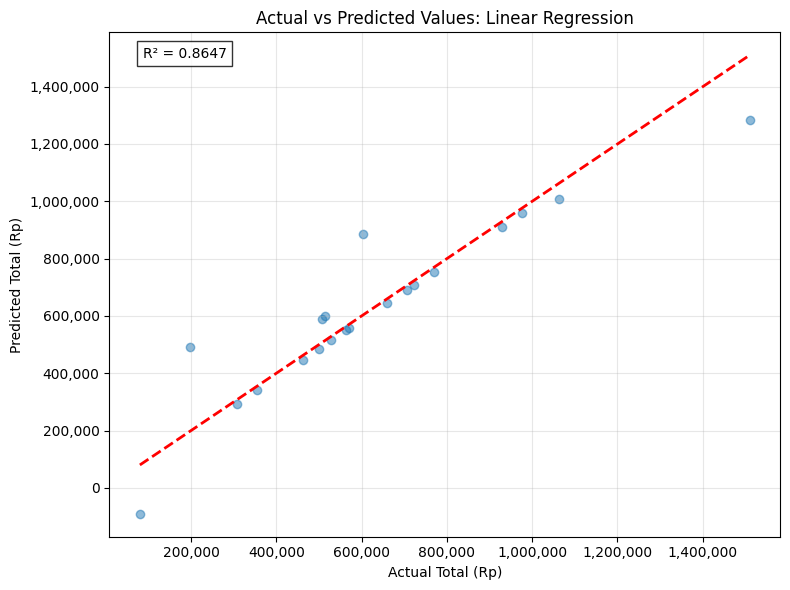


Interpretasi Model:
1. Model ini menjelaskan 86.5% variasi dalam data (berdasarkan R² Score).
2. Rata-rata kesalahan prediksi (MAE) adalah Rp 69,572.16
3. Untuk setiap pertambahan 1 unit Jumlah, Total akan bertambah sekitar Rp 119,225.51


In [24]:
# 19. Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print model performance metrics
print("Linear Regression")
print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): Rp {mae:,.2f}")
print(f"Root Mean Square Error (RMSE): Rp {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

# Print model coefficients
print("\nModel Parameters:")
print(f"Slope (coefficient): {model.coef_[0]:,.2f}")
print(f"Intercept: {model.intercept_:,.2f}")

# Create scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Total (Rp)')
plt.ylabel('Predicted Total (Rp)')
plt.title('Actual vs Predicted Values: Linear Regression')

# Format axis labels to show in proper currency format
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add R² value to the plot
plt.text(0.05, 0.95, f'R² = {r2:.4f}', 
         transform=plt.gca().transAxes, 
         fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Provide interpretation of the results
print("\nInterpretasi Model:")
print("1. Model ini menjelaskan {:.1f}% variasi dalam data (berdasarkan R² Score).".format(r2 * 100))
print("2. Rata-rata kesalahan prediksi (MAE) adalah Rp {:,.2f}".format(mae))
print("3. Untuk setiap pertambahan 1 unit Jumlah, Total akan bertambah sekitar Rp {:,.2f}".format(model.coef_[0]))

### D. Machine Learning – Prediksi Penjualan
- Model 2: Random Forest Regressor
21. Buat model Random Forest Regressor dengan parameter default.
22. Bandingkan hasil metrik dengan model Linear Regression (MAE, RMSE, R²).
23. Visualisasikan prediksi Random Forest (scatter plot).
24. Tambahkan kolom baru 'Prediksi_RF' ke dataframe dan tampilkan 5 data pertama.


In [25]:
# 21. Create and train a Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# Print Random Forest model performance metrics
print("\nRandom Forest Regressor")
print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): Rp {rf_mae:,.2f}")
print(f"Root Mean Square Error (RMSE): Rp {rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.4f}")


Random Forest Regressor
Model Performance Metrics:
Mean Absolute Error (MAE): Rp 26,260.00
Root Mean Square Error (RMSE): Rp 33,500.67
R² Score: 0.9886


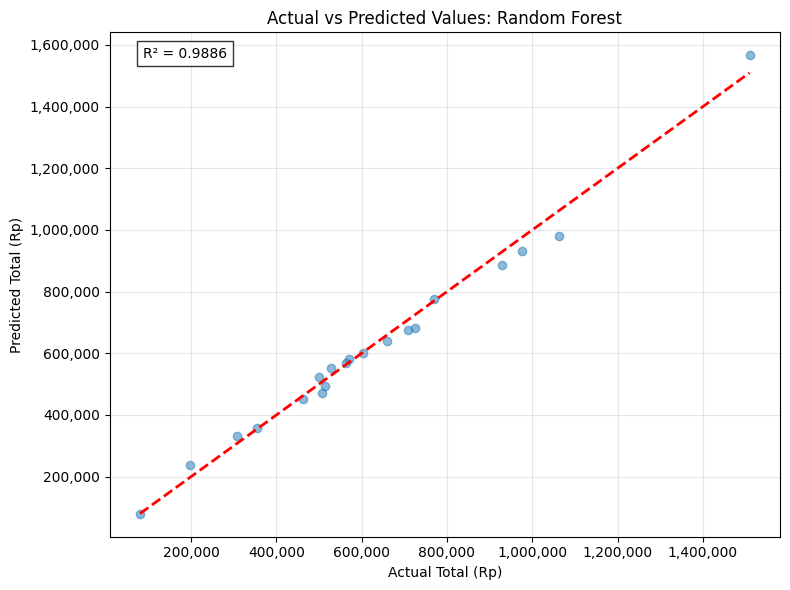

In [26]:
# 23. Create scatter plot for Random Forest predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Total (Rp)')
plt.ylabel('Predicted Total (Rp)')
plt.title('Actual vs Predicted Values: Random Forest')

# Format axis labels
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add R² value to the plot
plt.text(0.05, 0.95, f'R² = {rf_r2:.4f}', 
         transform=plt.gca().transAxes, 
         fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# 22. Compare metrics between Linear Regression and Random Forest
print("Perbandingan Metrik Model:")
metrics_comparison = {
    'Metrik': ['MAE', 'RMSE', 'R²'],
    'Linear Regression': [mae, rmse, r2],
    'Random Forest': [rf_mae, rf_rmse, rf_r2]
}

# Create comparison table
from tabulate import tabulate
metrics_df = pd.DataFrame(metrics_comparison)
metrics_df['Selisih'] = metrics_df['Random Forest'] - metrics_df['Linear Regression']

# Format the numeric columns
metrics_df['Linear Regression'] = metrics_df['Linear Regression'].apply(lambda x: f'{x:,.2f}')
metrics_df['Random Forest'] = metrics_df['Random Forest'].apply(lambda x: f'{x:,.2f}')
metrics_df['Selisih'] = metrics_df['Selisih'].apply(lambda x: f'{x:,.2f}')

print(tabulate(metrics_df, headers='keys', tablefmt='psql', showindex=False))

Perbandingan Metrik Model:
+----------+---------------------+-----------------+------------+
| Metrik   | Linear Regression   | Random Forest   | Selisih    |
|----------+---------------------+-----------------+------------|
| MAE      | 69,572.16           | 26,260.00       | -43,312.16 |
| RMSE     | 115,364.88          | 33,500.67       | -81,864.21 |
| R²       | 0.86                | 0.99            | 0.12       |
+----------+---------------------+-----------------+------------+


In [28]:
# 25. Add Random Forest predictions to the original dataframe
# First, make predictions for all data using the correct features
all_predictions = rf_model.predict(df[['Jumlah', 'Harga Satuan']])
df['Prediksi_RF'] = all_predictions

# Display the first 5 rows with actual and predicted values
print("\nPerbandingan 5 Data Pertama (Actual vs Predicted):")
display(df[['Jumlah', 'Total', 'Prediksi_RF']].head().style.format({
    'Total': 'Rp {:,.2f}'.format,
    'Prediksi_RF': 'Rp {:,.2f}'.format
}))

# Calculate and show average prediction error
error_rate = np.mean(np.abs((df['Total'] - df['Prediksi_RF']) / df['Total'])) * 100
print(f"\nRata-rata error prediksi: {error_rate:.2f}%")

# Interpretation of Random Forest results
print("\nInterpretasi Model Random Forest:")
print(f"1. Model Random Forest menjelaskan {rf_r2*100:.1f}% variasi dalam data (R² Score)")
print(f"2. Rata-rata kesalahan prediksi absolut (MAE) adalah Rp {rf_mae:,.2f}")
if rf_r2 > r2:
    print("3. Model Random Forest memberikan performa yang lebih baik dibandingkan Linear Regression")
else:
    print("3. Model Linear Regression memberikan performa yang lebih baik dibandingkan Random Forest")


Perbandingan 5 Data Pertama (Actual vs Predicted):


,Jumlah,Total,Prediksi_RF
0,5.000000,"Rp 570,980.00","Rp 582,113.34"
1,2.000000,"Rp 385,928.00","Rp 386,807.73"
2,7.000000,"Rp 408,317.00","Rp 428,667.10"
3,4.000000,"Rp 443,960.00","Rp 439,736.40"
4,1.000000,"Rp 197,127.00","Rp 238,549.14"



Rata-rata error prediksi: 4.21%

Interpretasi Model Random Forest:
1. Model Random Forest menjelaskan 98.9% variasi dalam data (R² Score)
2. Rata-rata kesalahan prediksi absolut (MAE) adalah Rp 26,260.00
3. Model Random Forest memberikan performa yang lebih baik dibandingkan Linear Regression


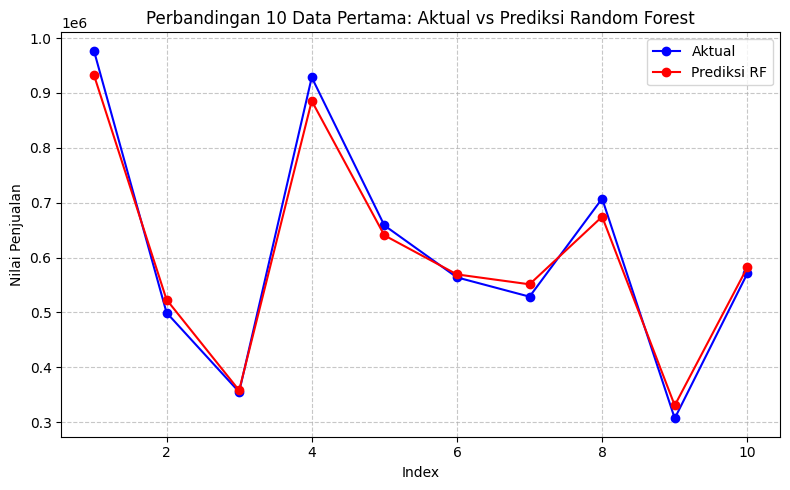

In [34]:
import matplotlib.pyplot as plt

# Ambil 5 data pertama
actual_5 = y_test.values[:10]
pred_5 = rf_pred[:10]

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), actual_5, label='Aktual', marker='o', color='blue')
plt.plot(range(1, 11), pred_5, label='Prediksi RF', marker='o', color='red')
plt.title('Perbandingan 10 Data Pertama: Aktual vs Prediksi Random Forest')
plt.xlabel('Index')
plt.ylabel('Nilai Penjualan')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()